In [13]:
!pip install qiskit
!pip install qiskit_aer
!!pip install pylatexenc
!pip install matplotlib
!pip install numpy

In [15]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram 
import numpy as np
import matplotlib.pyplot as plt 


Case: Constant-0: f(x)=0 (Expected: CONSTANT)

Quantum Circuit Diagram:


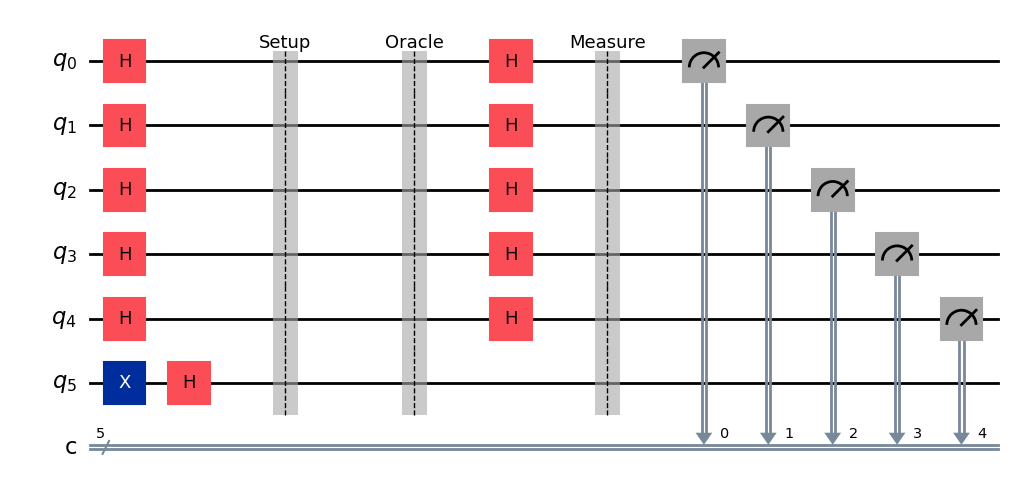

Measurement Counts: {'00000': 1024}
⚖️ Function is BALANCED (Measured NOT '00').

Histogram of Results:


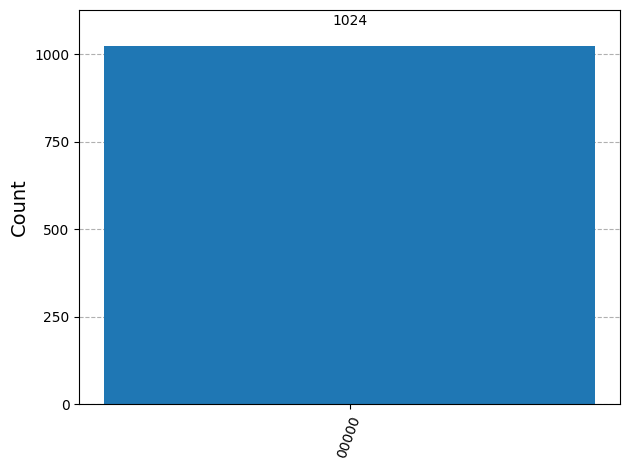


Case: Constant-1: f(x)=1 (Expected: CONSTANT)

Quantum Circuit Diagram:


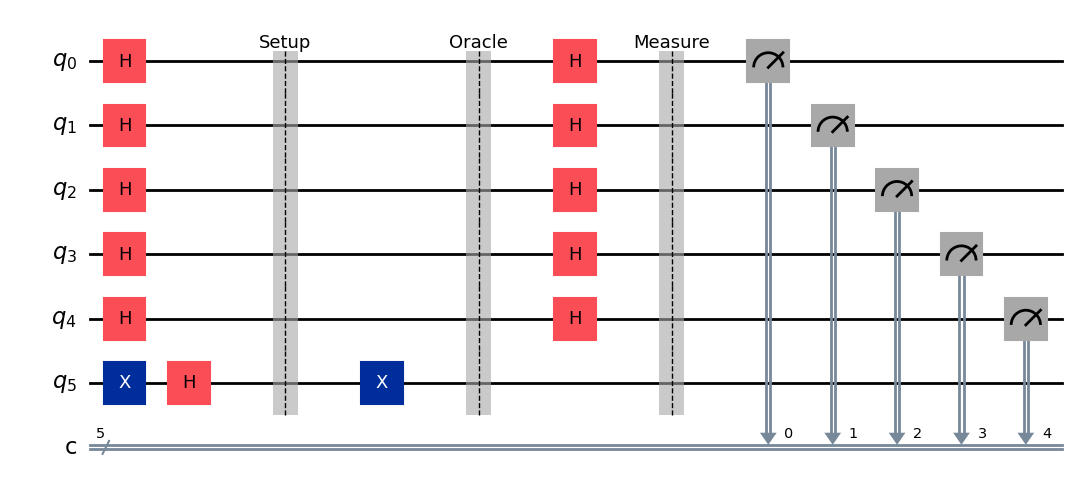

Measurement Counts: {'00000': 1024}
⚖️ Function is BALANCED (Measured NOT '00').

Histogram of Results:


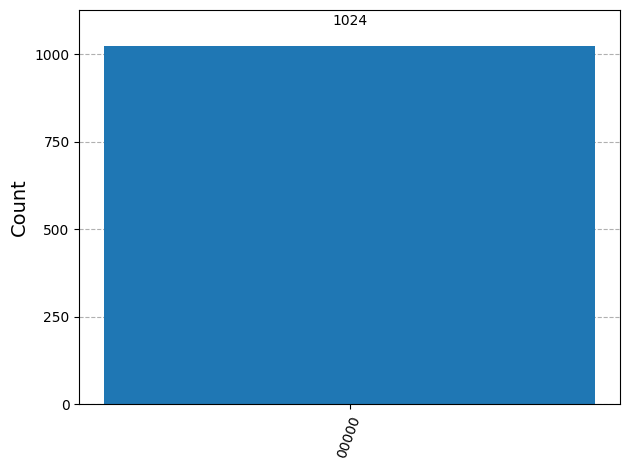


Case: Balanced-1: f(x)=x1 (Expected: BALANCED)

Quantum Circuit Diagram:


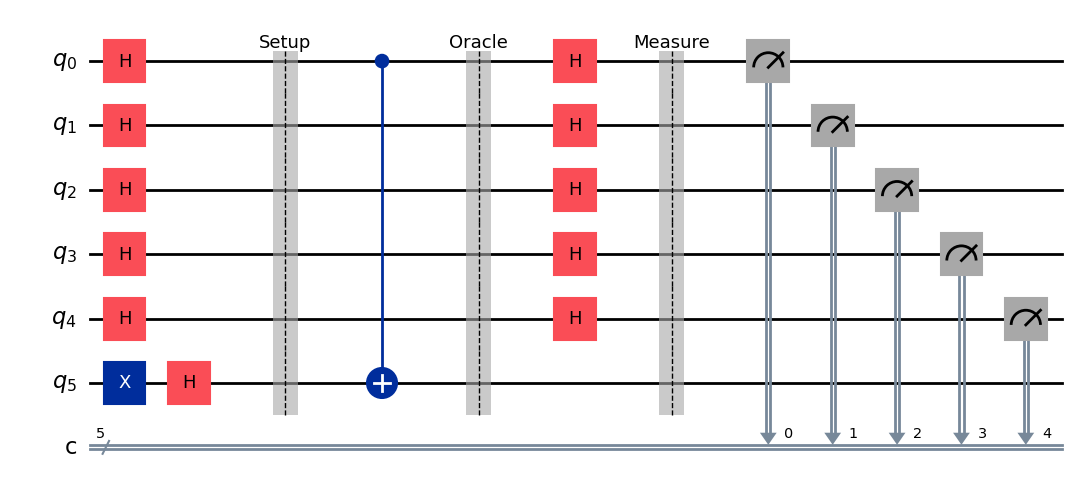

Measurement Counts: {'00001': 1024}
⚖️ Function is BALANCED (Measured NOT '00').

Histogram of Results:


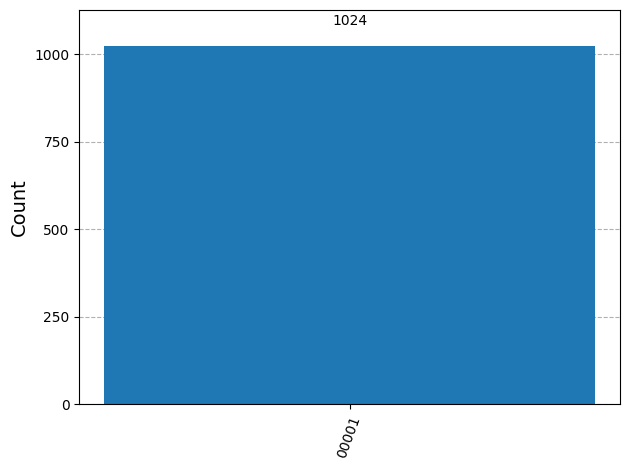


Case: Balanced-2: f(x)=x1 XOR x0 (Expected: BALANCED)

Quantum Circuit Diagram:


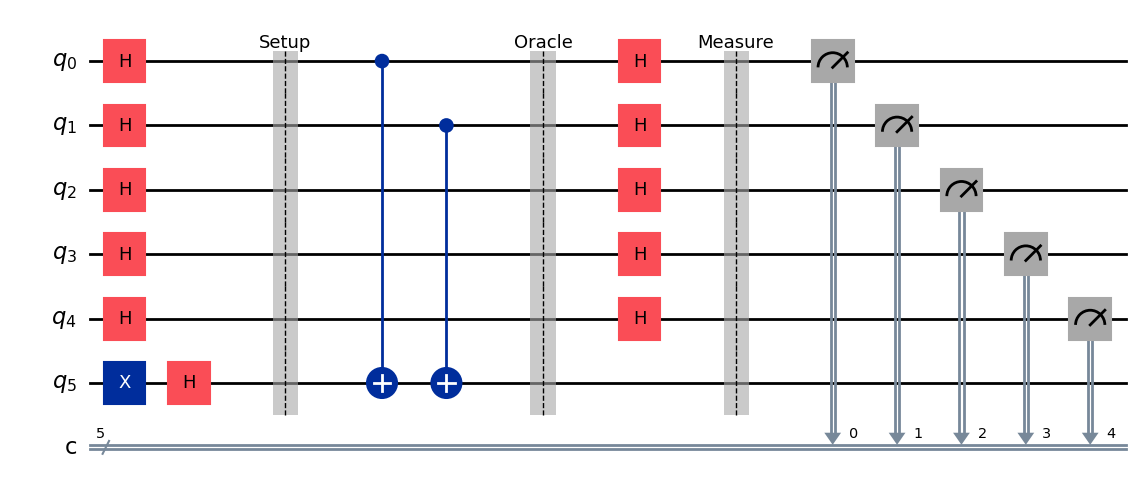

Measurement Counts: {'00011': 1024}
⚖️ Function is BALANCED (Measured NOT '00').

Histogram of Results:


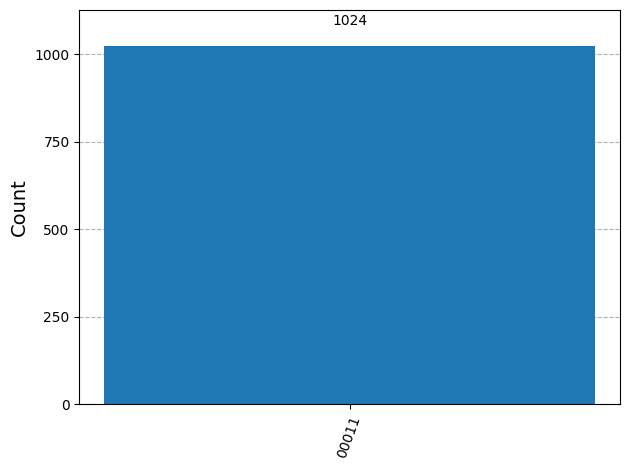


Case: Balanced-3: f(x)=NOT x0 (Expected: BALANCED)

Quantum Circuit Diagram:


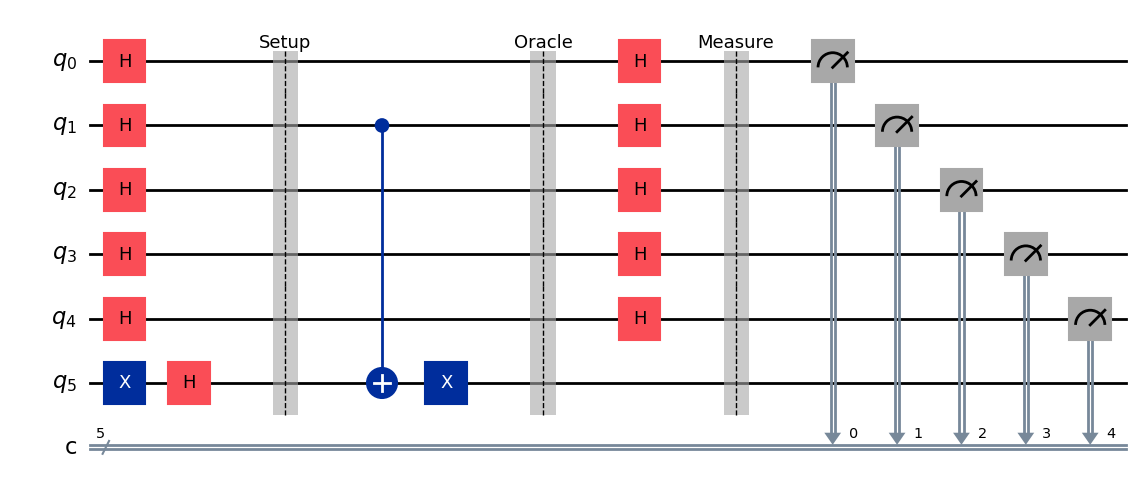

Measurement Counts: {'00010': 1024}
⚖️ Function is BALANCED (Measured NOT '00').

Histogram of Results:


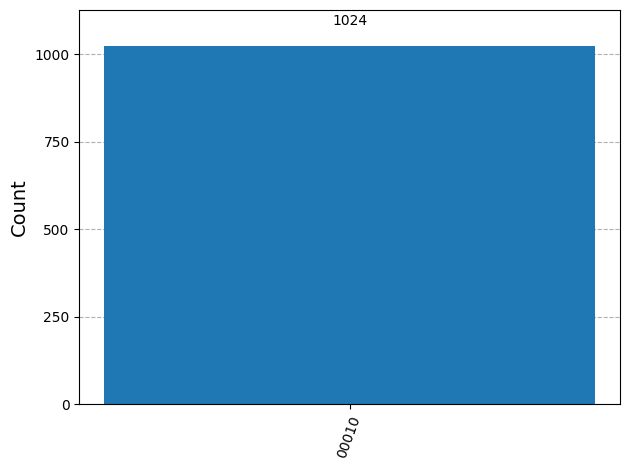

In [18]:
# --- Imports ---
from qiskit import QuantumCircuit, transpile
try:
    # ✅ For Qiskit v1.0+ (newer versions)
    from qiskit_aer import AerSimulator
except ImportError:
    # ✅ For older versions (< 0.45)
    from qiskit.providers.aer import AerSimulator

from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# --- Configuration ---
N_DATA_QUBITS = 5
N_TOTAL_QUBITS = N_DATA_QUBITS + 1
ANC = N_TOTAL_QUBITS - 1  # Index for the ancilla qubit (2)

# --- STEP A: Deutsch–Jozsa Framework ---
def create_dj_framework(oracle_circuit: QuantumCircuit) -> QuantumCircuit:
    """Creates the Deutsch–Jozsa circuit structure and inserts the oracle."""
    qc = QuantumCircuit(N_TOTAL_QUBITS, N_DATA_QUBITS)

    # 1. Initialize ancilla to |1>
    qc.x(ANC)

    # 2. Apply initial Hadamard gates (H^{⊗3})
    qc.h(range(N_TOTAL_QUBITS))
    qc.barrier(label='Setup')

    # 3. Insert oracle Uf
    qc.compose(oracle_circuit, range(N_TOTAL_QUBITS), inplace=True)
    qc.barrier(label='Oracle')

    # 4. Apply final Hadamards to data qubits (H^{⊗2})
    qc.h(range(N_DATA_QUBITS))
    qc.barrier(label='Measure')

    # 5. Measure the data qubits only
    qc.measure(range(N_DATA_QUBITS), range(N_DATA_QUBITS))

    return qc


# --- STEP B: Oracle Definitions ---

# CONSTANT FUNCTIONS
def oracle_constant_0():
    """f(x) = 0 (no change)."""
    oracle = QuantumCircuit(N_TOTAL_QUBITS, name='Uf_0')
    return oracle

def oracle_constant_1():
    """f(x) = 1 (flip ancilla)."""
    oracle = QuantumCircuit(N_TOTAL_QUBITS, name='Uf_1')
    oracle.x(ANC)
    return oracle

# BALANCED FUNCTIONS
def oracle_balanced_x1():
    """f(x) = x1."""
    oracle = QuantumCircuit(N_TOTAL_QUBITS, name='Uf_x1')
    oracle.cx(0, ANC)
    return oracle

def oracle_balanced_xor():
    """f(x) = x1 XOR x0."""
    oracle = QuantumCircuit(N_TOTAL_QUBITS, name='Uf_XOR')
    oracle.cx(0, ANC)
    oracle.cx(1, ANC)
    return oracle

def oracle_balanced_not_x0():
    """f(x) = NOT x0 = x0 XOR 1."""
    oracle = QuantumCircuit(N_TOTAL_QUBITS, name='Uf_NOT_x0')
    oracle.cx(1, ANC)
    oracle.x(ANC)
    return oracle


# --- STEP C: Simulation + Visualization ---
def run_dj_case(oracle_func, func_name, expected_type):
    print(f"\n=======================================================")
    print(f"Case: {func_name} (Expected: {expected_type})")
    print(f"=======================================================\n")

    # Create oracle and full DJ circuit
    oracle = oracle_func()
    dj_circuit = create_dj_framework(oracle)

    # --- 1. Draw the circuit ---
    print("Quantum Circuit Diagram:")
    display(dj_circuit.draw(output='mpl', fold=-1))
    plt.show()

    # --- 2. Simulate the circuit ---
    simulator = AerSimulator()
    compiled_circuit = transpile(dj_circuit, simulator)
    job = simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    counts = result.get_counts(dj_circuit)

    # --- 3. Show results ---
    print("Measurement Counts:", counts)
    if '00' in counts and counts['00'] > 0.9 * 1024:
        print("✅ Function is CONSTANT (Measured '00').")
    else:
        print("⚖️ Function is BALANCED (Measured NOT '00').")

    # --- 4. Plot histogram ---
    print("\nHistogram of Results:")
    display(plot_histogram(counts))
    plt.show()


# --- STEP D: Run All Cases ---
if __name__ == "__main__":
    # CONSTANT CASES
    run_dj_case(oracle_constant_0, "Constant-0: f(x)=0", "CONSTANT")
    run_dj_case(oracle_constant_1, "Constant-1: f(x)=1", "CONSTANT")

    # BALANCED CASES
    run_dj_case(oracle_balanced_x1, "Balanced-1: f(x)=x1", "BALANCED")
    run_dj_case(oracle_balanced_xor, "Balanced-2: f(x)=x1 XOR x0", "BALANCED")
    run_dj_case(oracle_balanced_not_x0, "Balanced-3: f(x)=NOT x0", "BALANCED")

